In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.interpolate import interp1d
from scipy.integrate import simps

from IPython.display import Audio,display
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
import librosa
from scipy.ndimage import convolve


In [8]:
def compute_envelopes(y):
    # Generate x values based on the length of y
    x = np.arange(len(y))
    
    # Find local maxima and minima
    peaks, _ = find_peaks(y)
    valleys, _ = find_peaks(-y)
    
    # Ensure peaks and valleys are sorted by their x positions
    peaks = np.sort(peaks)
    valleys = np.sort(valleys)
    
    # Create interpolating functions for upper and lower envelopes
    if len(peaks) > 1:
        upper_envelope = interp1d(x[peaks], y[peaks], kind='slinear', bounds_error=False, fill_value="extrapolate")
    else:
        upper_envelope = lambda x: np.max(y) * np.ones_like(x)

    if len(valleys) > 1:
        lower_envelope = interp1d(x[valleys], y[valleys], kind='slinear', bounds_error=False, fill_value="extrapolate")
    else:
        lower_envelope = lambda x: np.min(y) * np.ones_like(x)
    
    # Compute envelope values within the data range
    upper_env = upper_envelope(x)
    lower_env = lower_envelope(x)
    
    # Limit extrapolation by clipping the envelopes at the original range
    upper_env = np.clip(upper_env, np.min(y), np.max(y))
    lower_env = np.clip(lower_env, np.min(y), np.max(y))
    area = simps(upper_env - lower_env, x)
    return x, y, upper_env, lower_env, peaks, valleys

In [21]:
def area_envelopes(x, upper_env, lower_env):
    area = simps(upper_env - lower_env, x)
    return area

In [23]:
def loader(audio_folder):
    items = sorted(os.listdir(audio_folder))
    print('audio folder: ', audio_folder, ' with: ',len(items), ' items')
    specs = []
    name = []
    srs = []
    for item in items:
        path = os.path.join(audio_folder,item)
        
        y, sr = librosa.load(path, sr=None)  # Load with original sample rate
        
        n_mels = 300  # Number of Mel bands
        fmax = 10000  # Maximum frequency
        fmin = 2048
        mel_spectrogram = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels,fmin=fmin, fmax=fmax)

        # Convert to decibels
        mel_spectrogram_db = librosa.power_to_db(mel_spectrogram, ref=np.max)
        
        min_val = np.min(mel_spectrogram_db)
        mat = mel_spectrogram_db - min_val

        name.append(path)
        specs.append(mat)
        srs.append(sr)
    return name, specs, srs

In [103]:
list_eva = []
list_spec = []
list_signal =[] 
list_label = []
data = []
path = 'samples2024/agrovision/21-543/'
genotypes = os.listdir(path)
name, spec, srs = loader(path)

audio folder:  samples2024/agrovision/21-543/  with:  10  items


/tmp/ipykernel_425831/2102898774.py:2: DeprecationWarning: 'scipy.integrate.simps' is deprecated in favour of 'scipy.integrate.simpson' and will be removed in SciPy 1.14.0
  area = simps(upper_env - lower_env, x)


samples2024/agrovision/21-543/1.wav : 50.75
samples2024/agrovision/21-543/10.wav : 59.51
samples2024/agrovision/21-543/2.wav : 77.24
samples2024/agrovision/21-543/3.wav : 41.18
samples2024/agrovision/21-543/4.wav : 39.69
samples2024/agrovision/21-543/5.wav : 77.42
samples2024/agrovision/21-543/6.wav : 31.10
samples2024/agrovision/21-543/7.wav : 36.74
samples2024/agrovision/21-543/8.wav : 100.07
samples2024/agrovision/21-543/9.wav : 52.09
Average: 56.579241482969486


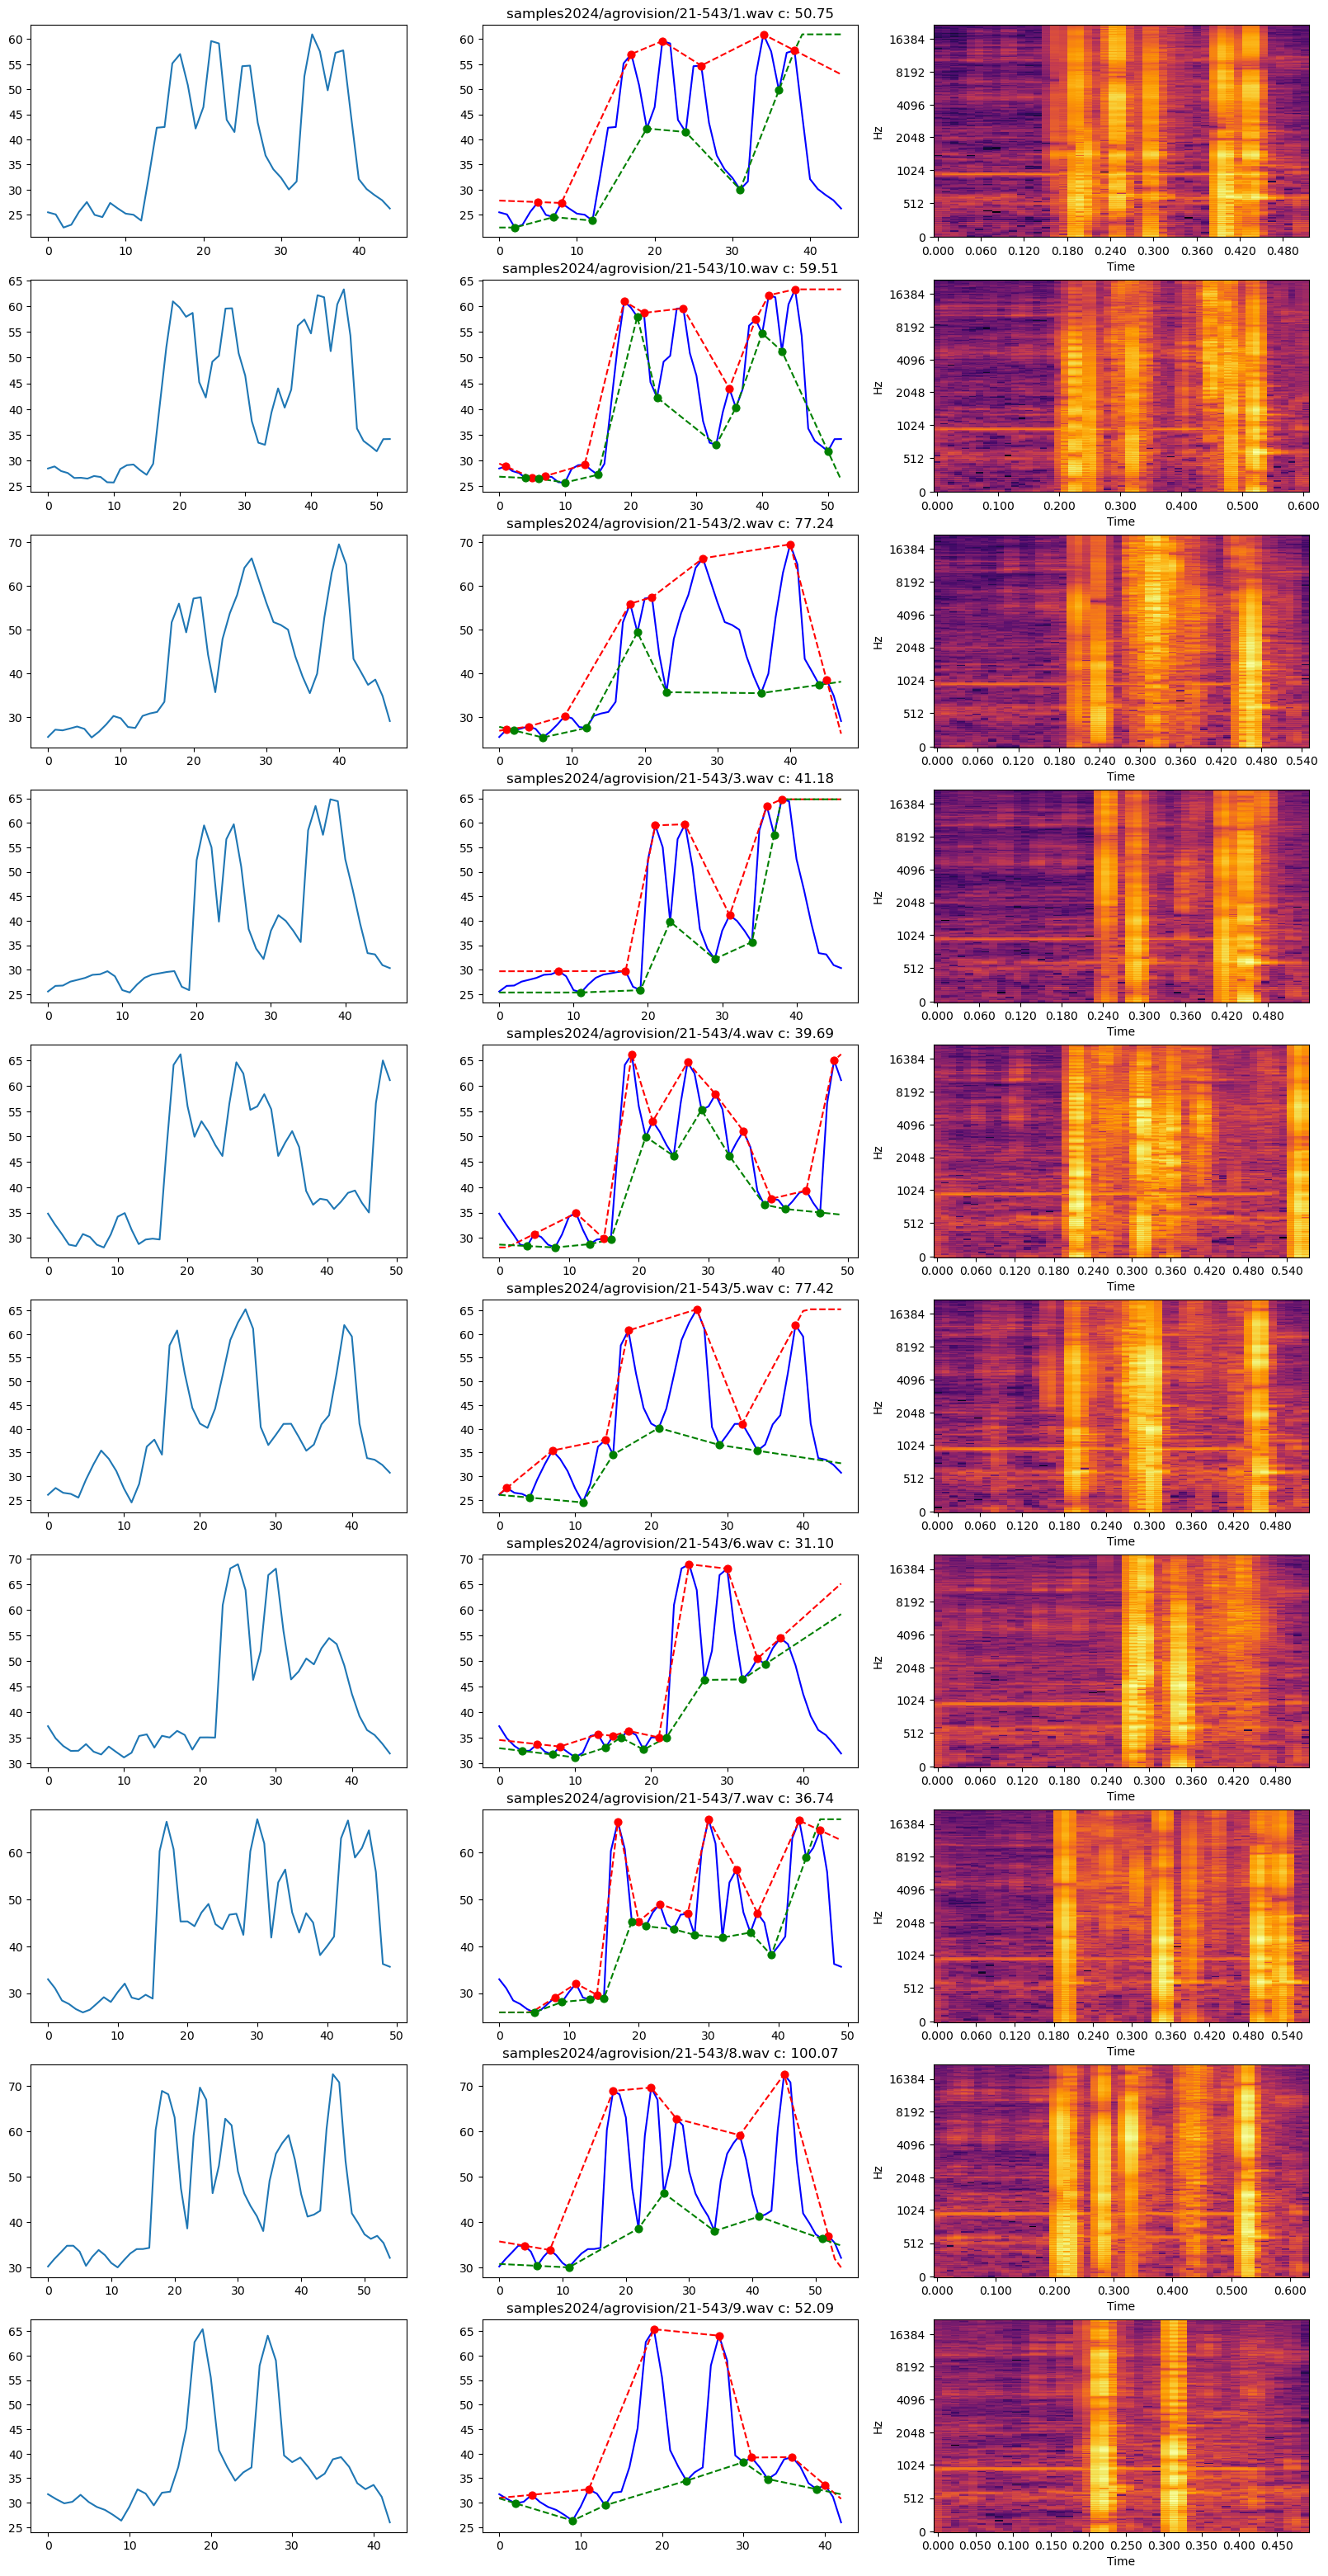

In [106]:
plt.figure(figsize=(20,200))
sample = 1
m = []
for n,[nome ,spe, sr] in enumerate(zip(name,spec,srs)):

    
    signal = np.median(spe,axis=0)


    plt.subplot(50,3,n*3+1)
    plt.plot(signal)

    
    plt.subplot(50,3,n*3+2)    
    x, original_y, upper_env, lower_env, peaks, valleys = compute_envelopes(signal)
    area = area_envelopes(x, upper_env, lower_env) / 10
    plt.plot(x, original_y, label='Original Data', color='blue')
    plt.plot(x, upper_env, '--', label='Upper Envelope', color='red')
    plt.plot(x, lower_env, '--', label='Lower Envelope', color='green')
    plt.title(f"{nome} c: {area:.2f}")
    plt.scatter(x[peaks], original_y[peaks], color='red', marker='o', s=40, zorder=5, label='Local Maxima')
    plt.scatter(x[valleys], original_y[valleys], color='green', marker='o', s=40, zorder=5, label='Local Minima')
    m.append(area)
    print(f"{nome} : {area:.2f}")
    #plt.figure(figsize=(5, 3))  # Increase figure size and DPI
    
    plt.subplot(50,3,n*3+3)
    librosa.display.specshow(spe, sr=sr, x_axis='time', y_axis='mel', cmap='inferno')
print(f"Average: {np.mean(m)}")
    #